# VoltAI – Battery Health & RUL Prediction

## Objective
Predict State of Health (SoH) and Remaining Useful Life (RUL)
using structured machine learning models with GroupKFold validation.

## Dataset
Battery cycle-level dataset (voltage, temperature, capacity).

## Methodology
- Feature engineering with lag features
- Grouped cross-validation by battery_id
- Baseline & advanced model comparison
- Evaluation using RMSE and R²
- SHAP for interpretability

In [9]:
# ============================
# 1️⃣ Imports
# ============================
import numpy as np
import pandas as pd
from zipfile import ZipFile
from google.colab import files
import io # Added for reading byte streams

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# ============================
# 2️⃣ Upload & Choose Dataset
# ============================

print("Upload your ZIP file containing the dataset, or a single CSV/Excel/JSON file:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

if file_name.endswith('.zip'):
    with ZipFile(file_name, 'r') as zip_ref:
        zip_contents = zip_ref.namelist()

        print("\nFiles inside ZIP:")
        for f in zip_contents:
            print("-", f)

        print("\nEnter the exact file name to load from the ZIP:")
        file_to_load = input().strip()

        with zip_ref.open(file_to_load) as f:
            if file_to_load.endswith('.csv'):
                data = pd.read_csv(f)
            elif file_to_load.endswith('.xlsx'):
                data = pd.read_excel(f)
            elif file_to_load.endswith('.json'):
                data = pd.read_json(f)
            else:
                raise ValueError("Unsupported file format inside ZIP! Please choose a .csv, .xlsx, or .json file.")
elif file_name.endswith(('.csv', '.xlsx', '.json')):
    file_content = uploaded[file_name]
    if file_name.endswith('.csv'):
        data = pd.read_csv(io.BytesIO(file_content))
    elif file_name.endswith('.xlsx'):
        data = pd.read_excel(io.BytesIO(file_content))
    elif file_name.endswith('.json'):
        data = pd.read_json(io.BytesIO(file_content))
else:
    raise ValueError("Unsupported file format! Please upload a .zip, .csv, .xlsx, or .json file.")

print("\nDataset loaded successfully!")
print("Columns:", data.columns.tolist())
print("Shape:", data.shape)

# ============================
# 3️⃣ Basic Validation
# ============================

required_cols = ['battery_id', 'cycle', 'soh', 'rul']
for col in required_cols:
    if col not in data.columns:
        raise ValueError(f"Required column '{col}' is missing!")

# ============================
# 4️⃣ Feature Engineering
# ============================
## Using electrochemical signals as degradation indicators
base_features = ['voltage', 'temperature', 'capacity']
LAGS = 5

for f in base_features:
    if f not in data.columns:
        raise ValueError(f"Feature '{f}' not found in dataset!")

    for lag in range(1, LAGS+1):
        data[f'{f}_lag{lag}'] = data.groupby('battery_id')[f].shift(lag)

    data[f'{f}_diff'] = data.groupby('battery_id')[f].diff()

# Drop NaNs created by lagging
data = data.dropna().reset_index(drop=True)

features = [c for c in data.columns if c not in ['battery_id', 'cycle', 'soh', 'rul']]
y_soh = data['soh']
y_rul = data['rul']
groups = data['battery_id']

print("\nTotal features used:", len(features))


# ============================
# 5️⃣ Models Definition
# ============================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ),
    "SVR": SVR(kernel='rbf', C=10, epsilon=0.01),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    )
}
from sklearn.model_selection import GridSearchCV

# Parameter grid for SVR
svr_param_grid = {
    'C': [1, 10, 50, 100],
    'epsilon': [0.001, 0.01, 0.05, 0.1],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

group_kfold = GroupKFold(n_splits=5)

svr = SVR()

grid_search_soh = GridSearchCV(
    svr,
    svr_param_grid,
    cv=group_kfold.split(data[features], y_soh, groups),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_rul = GridSearchCV(
    svr,
    svr_param_grid,
    cv=group_kfold.split(data[features], y_rul, groups),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("Tuning SVR for SoH...")
grid_search_soh.fit(StandardScaler().fit_transform(data[features]), y_soh)

print("Tuning SVR for RUL...")
grid_search_rul.fit(StandardScaler().fit_transform(data[features]), y_rul)

print("\nBest Parameters for SoH:", grid_search_soh.best_params_)
print("Best Parameters for RUL:", grid_search_rul.best_params_)
# ============================
# 6️⃣ GroupKFold Cross Validation
# ============================

n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

final_results = {}

for model_name in models.keys():
    final_results[model_name] = {
        'SoH_RMSE': [],
        'SoH_R2': [],
        'RUL_RMSE': [],
        'RUL_R2': []
    }

for fold, (train_idx, test_idx) in enumerate(gkf.split(data, y_soh, groups)):
    print(f"\n================ Fold {fold+1} ================")

    X_train = data.iloc[train_idx][features]
    X_test = data.iloc[test_idx][features]
    y_train_soh = y_soh.iloc[train_idx]
    y_test_soh = y_soh.iloc[test_idx]
    y_train_rul = y_rul.iloc[train_idx]
    y_test_rul = y_rul.iloc[test_idx]

# ============================
# ✅ Scaling (NO data leakage)
# ============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# IMPORTANT: fit scaler on TRAIN only, then transform TEST (prevents leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

for model_name, model in models.items():

    # Clone model separately for SoH and RUL
    import copy
    model_soh = copy.deepcopy(model)
    model_rul = copy.deepcopy(model)

    # Apply scaling only to models sensitive to feature magnitude
    # (Linear Regression & SVR). Tree-based models (RF/XGBoost) don't need scaling.
    if model_name in ["Linear Regression", "SVR", "SVR (Tuned)"]:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train.values, X_test.values

    # Train
    model_soh.fit(X_tr, y_train_soh)
    model_rul.fit(X_tr, y_train_rul)

    # Predict
    y_pred_soh = model_soh.predict(X_te)
    y_pred_rul = model_rul.predict(X_te)

    # Metrics
    r2_soh = r2_score(y_test_soh, y_pred_soh)
    rmse_soh = np.sqrt(mean_squared_error(y_test_soh, y_pred_soh))

    r2_rul = r2_score(y_test_rul, y_pred_rul)
    rmse_rul = np.sqrt(mean_squared_error(y_test_rul, y_pred_rul))

    final_results[model_name]['SoH_RMSE'].append(rmse_soh)
    final_results[model_name]['SoH_R2'].append(r2_soh)
    final_results[model_name]['RUL_RMSE'].append(rmse_rul)
    final_results[model_name]['RUL_R2'].append(r2_rul)
# ============================
# 7️⃣ Final Average Results
# ============================

print("\n======================================")
print("FINAL CROSS-VALIDATION AVERAGE RESULTS")
print("======================================")

for model_name in final_results:
    print(f"\n🔹 {model_name}")
    print(f"Average SoH RMSE: {np.mean(final_results[model_name]['SoH_RMSE']):.4f}")
    print(f"Average SoH R²:   {np.mean(final_results[model_name]['SoH_R2']):.4f}")
    print(f"Average RUL RMSE: {np.mean(final_results[model_name]['RUL_RMSE']):.4f}")
    print(f"Average RUL R²:   {np.mean(final_results[model_name]['RUL_R2']):.4f}")


Upload your ZIP file containing the dataset, or a single CSV/Excel/JSON file:


Saving battery_cycle_level_dataset_CLEAN_FINAL.csv to battery_cycle_level_dataset_CLEAN_FINAL (4).csv

Dataset loaded successfully!
Columns: ['battery_id', 'cycle', 'voltage', 'temperature', 'capacity', 'soh', 'rul']
Shape: (1415, 7)

Total features used: 21
Tuning SVR for SoH...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Tuning SVR for RUL...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters for SoH: {'C': 1, 'epsilon': 0.001, 'gamma': 'scale', 'kernel': 'rbf'}
Best Parameters for RUL: {'C': 1, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}

================ Fold 1 ================

================ Fold 2 ================

================ Fold 3 ================

================ Fold 4 ================

================ Fold 5 ================

FINAL CROSS-VALIDATION AVERAGE RESULTS

🔹 Linear Regression
Average SoH RMSE: 0.2084
Average SoH R²:   -1.5641
Average RUL RMSE: 62.4408
Average RUL R²:   -3.9605

🔹 Random Forest
Average 

  0%|          | 0/100 [00:00<?, ?it/s]

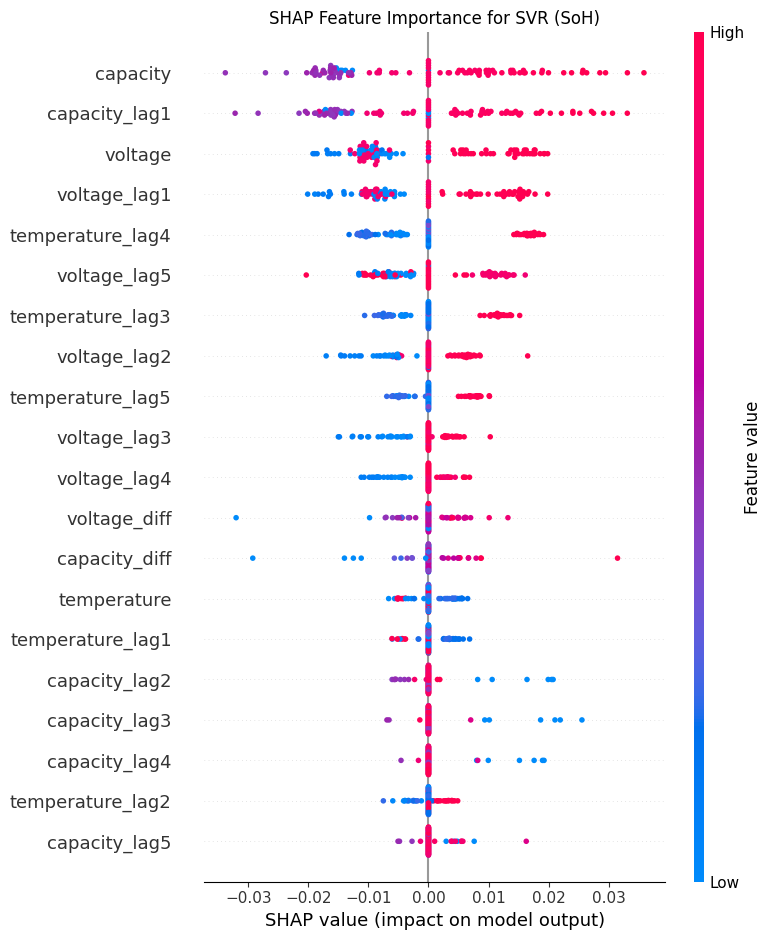

In [8]:
# ============================
# 8️⃣ Interpretability with SHAP
# ============================
import shap
import matplotlib.pyplot as plt

# Use the best SVR model for SoH from GridSearchCV
# The SVR model is already scaled by StandardScaler in GridSearchCV fitting.
model_for_shap = grid_search_soh.best_estimator_

# The X_test_scaled is available from the last fold's execution in the previous cell.
# We use a subset for speed and as background data for KernelExplainer.
# X_test_scaled is already scaled, which is appropriate for the SVR model.
X_sample_shap = X_test_scaled[:100]

explainer = shap.KernelExplainer(model_for_shap.predict, X_sample_shap)
shap_values = explainer.shap_values(X_sample_shap)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
# Ensure feature_names correspond to the scaled features
shap.summary_plot(shap_values, X_sample_shap, feature_names=features, show=False)
plt.title("SHAP Feature Importance for SVR (SoH)")
plt.tight_layout()
plt.show()